# G10 FX Carry Baseline Strategy

This notebook builds the first baseline G10 carry strategy from the clean monthly panel produced by `01_build_core_carry_panel.ipynb`.

The strategy is intentionally simple: each month, rank G10 currencies by the 1M carry signal, go long the three highest-carry currencies, and go short the three lowest-carry currencies. This is the benchmark we will use before adding transaction costs, EM currencies, options, regime filters, or machine-learning signals.


## Timing Convention

The input panel stores `carry_signal_1m` at month-end \(t\) and `realized_1m_forward_excess_return` for the following one-month holding period. Therefore, portfolio weights formed using month \(t\) carry signals are multiplied by the realized return already stored on the same row. This avoids look-ahead bias as long as we never use future carry rankings to choose the current month's weights.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "theo" / "data" / "processed").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing theo/data/processed and data/.")


ROOT = find_project_root()
PANEL_PATH = ROOT / "theo" / "data" / "processed" / "g10_1m_carry_panel.parquet"
G10_BASELINE = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
TOP_N = 3
BOTTOM_N = 3
MONTHS_PER_YEAR = 12

print(f"Project root: {ROOT}")
print(f"Input panel: {PANEL_PATH}")


Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo
Input panel: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo/theo/data/processed/g10_1m_carry_panel.parquet


## Load Clean Monthly Panel

The notebook loads only the processed G10 carry panel. If the file is missing or unreadable, later cells produce empty diagnostics instead of crashing.


In [2]:
def load_panel(path):
    if not path.exists():
        warnings.warn(f"Missing processed panel: {path}")
        return pd.DataFrame(), {"loaded": False, "rows": 0, "message": "missing file"}
    try:
        panel = pd.read_parquet(path)
        panel["month_end"] = pd.to_datetime(panel["month_end"], errors="coerce")
        numeric_cols = ["carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy"]
        for col in numeric_cols:
            if col in panel.columns:
                panel[col] = pd.to_numeric(panel[col], errors="coerce")
        panel = panel[panel["currency"].isin(G10_BASELINE)].copy()
        panel = panel.sort_values(["month_end", "currency"])
        return panel, {"loaded": True, "rows": len(panel), "message": ""}
    except Exception as exc:
        warnings.warn(f"Could not load processed panel: {repr(exc)}")
        return pd.DataFrame(), {"loaded": False, "rows": 0, "message": repr(exc)}


panel, load_status = load_panel(PANEL_PATH)
display(pd.DataFrame([load_status]))

if panel.empty:
    display(Markdown("No panel data loaded."))
else:
    display(panel.head())
    print(f"Rows: {len(panel):,}")
    print(f"Currencies: {sorted(panel['currency'].dropna().unique())}")
    print(f"Date range: {panel['month_end'].min().date()} to {panel['month_end'].max().date()}")


,loaded,rows,message
0,True,2106,


,month_end,currency,tenor,spot_ticker,forward_ticker,raw_pair,raw_units,invert_to_usd_per_ccy,forward_quote_type,point_size_used,raw_spot,raw_forward_input,raw_forward_outright,spot_usd_per_ccy,forward_1m_usd_per_ccy,carry_signal_1m,next_month_spot_usd_per_ccy,realized_1m_forward_excess_return
0,2007-01-31,AUD,1M,AUD Curncy,AUD1M Curncy,AUDUSD,USD per AUD,False,points_like,0.0001,0.7769,-5.63,0.776337,0.776900,0.776337,0.000725,0.787900,0.014894
234,2007-01-31,CAD,1M,CAD Curncy,CAD1M Curncy,USDCAD,CAD per USD,True,points_like,0.0001,1.1769,-9.55,1.175945,0.849690,0.850380,-0.000811,0.854774,0.005167
468,2007-01-31,CHF,1M,CHF Curncy,CHF1M Curncy,USDCHF,CHF per USD,True,points_like,0.0001,1.2441,-31.00,1.241000,0.803794,0.805802,-0.002492,0.819941,0.017547
702,2007-01-31,EUR,1M,EUR Curncy,EUR1M Curncy,EURUSD,USD per EUR,False,points_like,0.0001,1.3032,17.15,1.304915,1.303200,1.304915,-0.001314,1.322900,0.013783
936,2007-01-31,GBP,1M,GBP Curncy,GBP1M Curncy,GBPUSD,USD per GBP,False,points_like,0.0001,1.9655,-0.40,1.965460,1.965500,1.965460,0.000020,1.963900,-0.000794


Rows: 2,106
Currencies: ['AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'NZD', 'SEK']
Date range: 2007-01-31 to 2026-06-30


## Input Coverage Check

Each month should have enough currencies with both a carry signal and the next-month realized return. The last month is expected to have missing realized returns because the next month's spot is not yet in the panel.


In [3]:
required_cols = ["month_end", "currency", "carry_signal_1m", "realized_1m_forward_excess_return"]
missing_required_cols = [c for c in required_cols if c not in panel.columns]
if missing_required_cols:
    warnings.warn(f"Panel is missing required columns: {missing_required_cols}")

if panel.empty or missing_required_cols:
    coverage_by_month = pd.DataFrame(columns=["month_end", "n_currencies", "n_valid_signal", "n_valid_return", "n_valid_both"])
    coverage_by_currency = pd.DataFrame(columns=["currency", "months", "missing_signal", "missing_realized_return", "first_month", "last_month"])
else:
    tmp = panel.copy()
    tmp["valid_signal"] = tmp["carry_signal_1m"].notna()
    tmp["valid_return"] = tmp["realized_1m_forward_excess_return"].notna()
    tmp["valid_both"] = tmp["valid_signal"] & tmp["valid_return"]
    coverage_by_month = (tmp.groupby("month_end")
        .agg(
            n_currencies=("currency", "nunique"),
            n_valid_signal=("valid_signal", "sum"),
            n_valid_return=("valid_return", "sum"),
            n_valid_both=("valid_both", "sum"),
        )
        .reset_index())
    coverage_by_currency = (tmp.groupby("currency")
        .agg(
            months=("month_end", "nunique"),
            missing_signal=("carry_signal_1m", lambda x: int(x.isna().sum())),
            missing_realized_return=("realized_1m_forward_excess_return", lambda x: int(x.isna().sum())),
            first_month=("month_end", "min"),
            last_month=("month_end", "max"),
        )
        .reset_index())
    coverage_by_currency["first_month"] = coverage_by_currency["first_month"].dt.date.astype(str)
    coverage_by_currency["last_month"] = coverage_by_currency["last_month"].dt.date.astype(str)

display(Markdown("### Monthly coverage, first and last rows"))
display(pd.concat([coverage_by_month.head(6), coverage_by_month.tail(6)]).drop_duplicates() if not coverage_by_month.empty else coverage_by_month)

display(Markdown("### Currency coverage"))
display(coverage_by_currency)


### Monthly coverage, first and last rows

,month_end,n_currencies,n_valid_signal,n_valid_return,n_valid_both
0,2007-01-31,9,9,9,9
1,2007-02-28,9,9,9,9
2,2007-03-31,9,9,9,9
3,2007-04-30,9,9,9,9
4,2007-05-31,9,9,9,9
5,2007-06-30,9,9,9,9
228,2026-01-31,9,9,9,9
229,2026-02-28,9,9,9,9
230,2026-03-31,9,9,9,9
231,2026-04-30,9,9,9,9


### Currency coverage

,currency,months,missing_signal,missing_realized_return,first_month,last_month
0,AUD,234,0,1,2007-01-31,2026-06-30
1,CAD,234,0,1,2007-01-31,2026-06-30
2,CHF,234,0,1,2007-01-31,2026-06-30
3,EUR,234,0,1,2007-01-31,2026-06-30
4,GBP,234,0,1,2007-01-31,2026-06-30
5,JPY,234,0,1,2007-01-31,2026-06-30
6,NOK,234,0,1,2007-01-31,2026-06-30
7,NZD,234,0,1,2007-01-31,2026-06-30
8,SEK,234,0,1,2007-01-31,2026-06-30


## Build Equal-Weight Long-Short Portfolio

For each month:

- sort currencies by `carry_signal_1m`
- long the top three currencies, with each long weight equal to `+1/3`
- short the bottom three currencies, with each short weight equal to `-1/3`
- hold all other currencies at zero weight

A month is skipped if fewer than six currencies have both a valid signal and a valid realized return.


In [4]:
def assign_carry_weights(month_df, top_n=TOP_N, bottom_n=BOTTOM_N):
    sub = month_df.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"]).copy()
    sub = sub.sort_values(["carry_signal_1m", "currency"], ascending=[True, True])
    sub["weight"] = 0.0
    sub["basket"] = "middle"

    if len(sub) < top_n + bottom_n:
        sub["basket"] = "insufficient_data"
        return sub

    low_idx = sub.head(bottom_n).index
    high_idx = sub.tail(top_n).index
    sub.loc[low_idx, "weight"] = -1.0 / bottom_n
    sub.loc[low_idx, "basket"] = "short_low_carry"
    sub.loc[high_idx, "weight"] = 1.0 / top_n
    sub.loc[high_idx, "basket"] = "long_high_carry"
    return sub


if panel.empty or missing_required_cols:
    weights_panel = pd.DataFrame(columns=list(panel.columns) + ["weight", "basket", "weighted_return"])
else:
    pieces = []
    for month_end, month_df in panel.groupby("month_end", sort=True):
        assigned = assign_carry_weights(month_df)
        assigned["month_end"] = month_end
        pieces.append(assigned)
    weights_panel = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame(columns=list(panel.columns) + ["weight", "basket"])
    weights_panel["weighted_return"] = weights_panel["weight"] * weights_panel["realized_1m_forward_excess_return"]

if not weights_panel.empty:
    weights_panel = weights_panel.sort_values(["month_end", "weight", "currency"], ascending=[True, True, True])

display(weights_panel.head(18))


,month_end,currency,tenor,spot_ticker,forward_ticker,raw_pair,raw_units,invert_to_usd_per_ccy,forward_quote_type,point_size_used,raw_spot,raw_forward_input,raw_forward_outright,spot_usd_per_ccy,forward_1m_usd_per_ccy,carry_signal_1m,next_month_spot_usd_per_ccy,realized_1m_forward_excess_return,weight,basket,weighted_return
1,2007-01-31,CHF,1M,CHF Curncy,CHF1M Curncy,USDCHF,CHF per USD,True,points_like,0.0001,1.2441,-31.00,1.241000,0.803794,0.805802,-0.002492,0.819941,0.017547,-0.333333,short_low_carry,-0.005849
0,2007-01-31,JPY,1M,JPY Curncy,JPY1M Curncy,USDJPY,JPY per USD,True,points_like,0.0100,120.7000,-45.84,120.241600,0.008285,0.008317,-0.003798,0.008435,0.014184,-0.333333,short_low_carry,-0.004728
2,2007-01-31,SEK,1M,SEK Curncy,SEK1M Curncy,USDSEK,SEK per USD,True,points_like,0.0001,6.9490,-116.50,6.937350,0.143906,0.144147,-0.001677,0.142961,-0.008227,-0.333333,short_low_carry,0.002742
5,2007-01-31,CAD,1M,CAD Curncy,CAD1M Curncy,USDCAD,CAD per USD,True,points_like,0.0001,1.1769,-9.55,1.175945,0.849690,0.850380,-0.000811,0.854774,0.005167,0.000000,middle,0.000000
3,2007-01-31,EUR,1M,EUR Curncy,EUR1M Curncy,EURUSD,USD per EUR,False,points_like,0.0001,1.3032,17.15,1.304915,1.303200,1.304915,-0.001314,1.322900,0.013783,0.000000,middle,0.000000
4,2007-01-31,NOK,1M,NOK Curncy,NOK1M Curncy,USDNOK,NOK per USD,True,points_like,0.0001,6.2419,-68.25,6.235075,0.160208,0.160383,-0.001093,0.163074,0.016776,0.000000,middle,0.000000
7,2007-01-31,AUD,1M,AUD Curncy,AUD1M Curncy,AUDUSD,USD per AUD,False,points_like,0.0001,0.7769,-5.63,0.776337,0.776900,0.776337,0.000725,0.787900,0.014894,0.333333,long_high_carry,0.004965
6,2007-01-31,GBP,1M,GBP Curncy,GBP1M Curncy,GBPUSD,USD per GBP,False,points_like,0.0001,1.9655,-0.40,1.965460,1.965500,1.965460,0.000020,1.963900,-0.000794,0.333333,long_high_carry,-0.000265
8,2007-01-31,NZD,1M,NZD Curncy,NZD1M Curncy,NZDUSD,USD per NZD,False,points_like,0.0001,0.6912,-11.10,0.690090,0.691200,0.690090,0.001608,0.701400,0.016389,0.333333,long_high_carry,0.005463
10,2007-02-28,CHF,1M,CHF Curncy,CHF1M Curncy,USDCHF,CHF per USD,True,points_like,0.0001,1.2196,-33.25,1.216275,0.819941,0.822182,-0.002726,0.822707,0.000638,-0.333333,short_low_carry,-0.000213


## Portfolio Returns

The portfolio return in a row dated month-end \(t\) is the return earned over the next one-month holding period using the month \(t\) carry ranking. This is the baseline gross return before transaction costs.


In [5]:
def build_portfolio_returns(weights):
    if weights.empty:
        return pd.DataFrame(columns=[
            "month_end", "portfolio_return", "n_currencies", "long_currencies", "short_currencies",
            "gross_long_weight", "gross_short_weight", "net_weight", "gross_weight",
        ])
    rows = []
    for dt, sub in weights.groupby("month_end"):
        long_names = sorted(sub.loc[sub["basket"] == "long_high_carry", "currency"].tolist())
        short_names = sorted(sub.loc[sub["basket"] == "short_low_carry", "currency"].tolist())
        rows.append({
            "month_end": dt,
            "portfolio_return": sub["weighted_return"].sum(),
            "n_currencies": sub["currency"].nunique(),
            "long_currencies": ", ".join(long_names),
            "short_currencies": ", ".join(short_names),
            "gross_long_weight": sub.loc[sub["weight"] > 0, "weight"].sum(),
            "gross_short_weight": sub.loc[sub["weight"] < 0, "weight"].sum(),
            "net_weight": sub["weight"].sum(),
            "gross_weight": sub["weight"].abs().sum(),
        })
    out = pd.DataFrame(rows).sort_values("month_end")
    valid_weights = (
        np.isclose(out["gross_long_weight"], 1.0)
        & np.isclose(out["gross_short_weight"], -1.0)
        & np.isclose(out["net_weight"], 0.0)
        & np.isclose(out["gross_weight"], 2.0)
    )
    out = out[valid_weights].copy()
    out["wealth_index"] = (1.0 + out["portfolio_return"]).cumprod()
    out["cumulative_return"] = out["wealth_index"] - 1.0
    out["running_peak"] = out["wealth_index"].cummax()
    out["drawdown"] = out["wealth_index"] / out["running_peak"] - 1.0
    out["rolling_12m_return"] = out["wealth_index"] / out["wealth_index"].shift(12) - 1.0
    return out


portfolio_returns = build_portfolio_returns(weights_panel)
print(f"Return months: {len(portfolio_returns):,}")
display(portfolio_returns.head())
display(portfolio_returns.tail())


Return months: 233


,month_end,portfolio_return,n_currencies,long_currencies,short_currencies,gross_long_weight,gross_short_weight,net_weight,gross_weight,wealth_index,cumulative_return,running_peak,drawdown,rolling_12m_return
0,2007-01-31,0.002329,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.002329,0.002329,1.002329,0.0,NaN
1,2007-02-28,0.015620,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.017985,0.017985,1.017985,0.0,NaN
2,2007-03-31,0.018530,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.036848,0.036848,1.036848,0.0,NaN
3,2007-04-30,0.019652,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.057225,0.057225,1.057225,0.0,NaN
4,2007-05-31,0.032373,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.091451,0.091451,1.091451,0.0,NaN


,month_end,portfolio_return,n_currencies,long_currencies,short_currencies,gross_long_weight,gross_short_weight,net_weight,gross_weight,wealth_index,cumulative_return,running_peak,drawdown,rolling_12m_return
228,2026-01-31,0.014207,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.379830,0.379830,1.379830,0.000000,0.052179
229,2026-02-28,0.013742,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.398791,0.398791,1.398791,0.000000,0.061760
230,2026-03-31,0.022149,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.429773,0.429773,1.429773,0.000000,0.115840
231,2026-04-30,0.004491,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.436195,0.436195,1.436195,0.000000,0.107041
232,2026-05-31,-0.002809,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.432161,0.432161,1.436195,-0.002809,0.107446


## Baseline Performance Summary

These statistics describe the gross long-short carry portfolio. They should be interpreted as a diagnostic benchmark, not as investable performance yet, because transaction costs and implementation constraints have not been applied.


In [6]:
def max_drawdown(return_series):
    if return_series.empty:
        return np.nan
    wealth = (1.0 + return_series).cumprod()
    dd = wealth / wealth.cummax() - 1.0
    return dd.min()


def performance_summary(returns, months_per_year=MONTHS_PER_YEAR):
    r = returns.dropna().astype(float)
    if r.empty:
        return pd.DataFrame([{
            "months": 0,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "skewness": np.nan,
            "hit_rate": np.nan,
        }])
    compounded_annual_return = (1.0 + r).prod() ** (months_per_year / len(r)) - 1.0
    annual_vol = r.std(ddof=1) * np.sqrt(months_per_year)
    sharpe = compounded_annual_return / annual_vol if annual_vol and pd.notna(annual_vol) else np.nan
    return pd.DataFrame([{
        "months": len(r),
        "annualized_return": compounded_annual_return,
        "annualized_volatility": annual_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_drawdown(r),
        "skewness": r.skew(),
        "hit_rate": (r > 0).mean(),
        "best_month": r.max(),
        "worst_month": r.min(),
    }])

summary = performance_summary(portfolio_returns["portfolio_return"] if not portfolio_returns.empty else pd.Series(dtype=float))
display(summary.style.format({
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "skewness": "{:.2f}",
    "hit_rate": "{:.2%}",
    "best_month": "{:.2%}",
    "worst_month": "{:.2%}",
}))


,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,best_month,worst_month
0,233,1.87%,7.80%,0.24,-27.26%,-0.76,57.08%,7.56%,-11.60%


## Worst Months and Calendar-Year Performance

Carry strategies often earn small premia in calm periods but lose sharply during funding squeezes, dollar rallies, and volatility shocks. The worst-month table is an early check for that crash-risk profile.


In [7]:
if portfolio_returns.empty:
    worst_10_months = pd.DataFrame(columns=["month_end", "portfolio_return", "long_currencies", "short_currencies"])
    yearly_performance = pd.DataFrame(columns=["year", "months", "calendar_year_return", "annualized_volatility", "sharpe_ratio", "hit_rate", "max_drawdown"])
else:
    worst_10_months = (portfolio_returns
        .sort_values("portfolio_return")
        .head(10)
        [["month_end", "portfolio_return", "long_currencies", "short_currencies", "drawdown"]]
        .copy())

    yr = portfolio_returns.copy()
    yr["year"] = yr["month_end"].dt.year
    rows = []
    for year, sub in yr.groupby("year"):
        r = sub["portfolio_return"].dropna()
        vol = r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR) if len(r) > 1 else np.nan
        year_return = (1.0 + r).prod() - 1.0 if len(r) else np.nan
        rows.append({
            "year": year,
            "months": len(r),
            "calendar_year_return": year_return,
            "annualized_volatility": vol,
            "sharpe_ratio": year_return / vol if vol and pd.notna(vol) else np.nan,
            "hit_rate": (r > 0).mean() if len(r) else np.nan,
            "max_drawdown": max_drawdown(r),
        })
    yearly_performance = pd.DataFrame(rows)

display(Markdown("### Worst 10 months"))
display(worst_10_months.style.format({"portfolio_return": "{:.2%}", "drawdown": "{:.2%}"}) if not worst_10_months.empty else worst_10_months)

display(Markdown("### Performance by calendar year"))
display(yearly_performance.style.format({
    "calendar_year_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "hit_rate": "{:.2%}",
    "max_drawdown": "{:.2%}",
}) if not yearly_performance.empty else yearly_performance)


### Worst 10 months

,month_end,portfolio_return,long_currencies,short_currencies,drawdown
20,2008-09-30 00:00:00,-11.60%,"AUD, NOK, NZD","CHF, EUR, JPY",-22.35%
157,2020-02-29 00:00:00,-6.41%,"CAD, NOK, NZD","CHF, EUR, JPY",-13.23%
19,2008-08-31 00:00:00,-6.32%,"AUD, NOK, NZD","CAD, CHF, JPY",-12.16%
95,2014-12-31 00:00:00,-6.04%,"AUD, NOK, NZD","CHF, EUR, JPY",-8.94%
142,2018-11-30 00:00:00,-5.13%,"AUD, CAD, NZD","CHF, JPY, SEK",-7.17%
9,2007-10-31 00:00:00,-4.51%,"AUD, GBP, NZD","CHF, EUR, JPY",-4.78%
55,2011-08-31 00:00:00,-4.16%,"AUD, NOK, NZD","CHF, GBP, JPY",-9.58%
76,2013-05-31 00:00:00,-4.11%,"AUD, NOK, NZD","CHF, EUR, JPY",-7.00%
187,2022-08-31 00:00:00,-3.96%,"AUD, CAD, NZD","CHF, EUR, JPY",-3.96%
39,2010-04-30 00:00:00,-3.91%,"AUD, NOK, NZD","CHF, JPY, SEK",-8.14%


### Performance by calendar year

,year,months,calendar_year_return,annualized_volatility,sharpe_ratio,hit_rate,max_drawdown
0,2007,12,1.41%,9.06%,0.16,58.33%,-7.09%
1,2008,12,-21.71%,13.54%,-1.60,33.33%,-24.64%
2,2009,12,25.48%,8.46%,3.01,83.33%,-1.69%
3,2010,12,1.34%,9.23%,0.15,50.00%,-7.50%
4,2011,12,6.11%,8.42%,0.73,50.00%,-6.15%
5,2012,12,9.57%,7.88%,1.21,66.67%,-5.71%
6,2013,12,-5.36%,7.41%,-0.72,41.67%,-8.97%
7,2014,12,-0.84%,7.83%,-0.11,58.33%,-7.70%
8,2015,12,-1.34%,9.28%,-0.14,33.33%,-10.74%
9,2016,12,7.82%,4.22%,1.85,66.67%,-1.57%


## Performance Plots

The first three charts show cumulative return, drawdown, and rolling 12-month return. These are the fastest visual checks for carry-like behavior: slow compounding punctuated by sharp drawdowns is a classic warning sign.


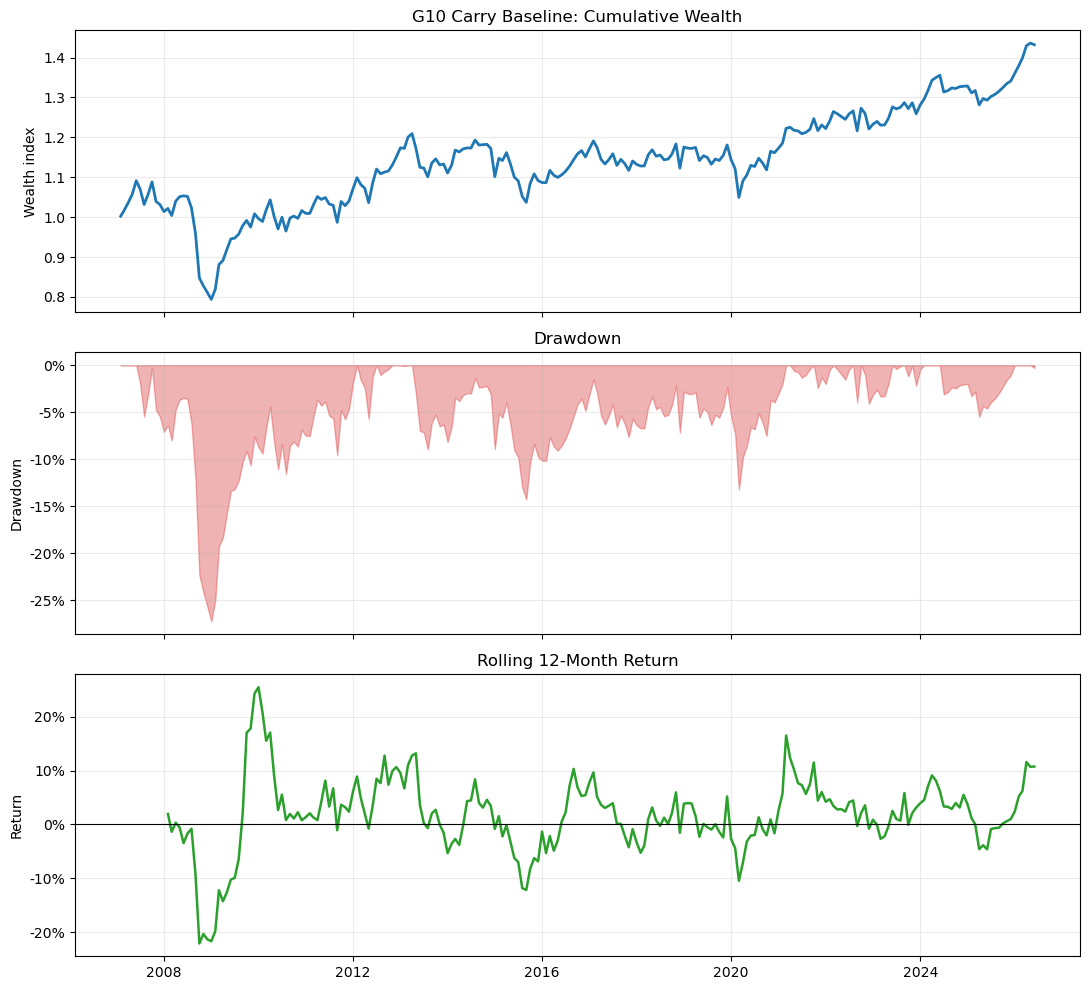

In [8]:
if plt is None or portfolio_returns.empty:
    display(Markdown("Performance plots skipped because matplotlib is unavailable or no portfolio returns were created."))
else:
    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    axes[0].plot(portfolio_returns["month_end"], portfolio_returns["wealth_index"], color="#1f77b4", linewidth=2)
    axes[0].set_title("G10 Carry Baseline: Cumulative Wealth")
    axes[0].set_ylabel("Wealth index")
    axes[0].grid(alpha=0.25)

    axes[1].fill_between(portfolio_returns["month_end"], portfolio_returns["drawdown"], 0, color="#d62728", alpha=0.35)
    axes[1].set_title("Drawdown")
    axes[1].set_ylabel("Drawdown")
    axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    axes[1].grid(alpha=0.25)

    axes[2].plot(portfolio_returns["month_end"], portfolio_returns["rolling_12m_return"], color="#2ca02c", linewidth=1.8)
    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].set_title("Rolling 12-Month Return")
    axes[2].set_ylabel("Return")
    axes[2].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## Basket Composition

This section shows which currencies are selected most often. The rolling chart uses a 36-month selection frequency, so a value near 1 means a currency was almost always in that basket over the prior three years.


,currency,long_selection_rate,short_selection_rate
7,NZD,91.4%,0.0%
0,AUD,76.0%,0.0%
6,NOK,66.1%,0.0%
1,CAD,34.8%,6.9%
4,GBP,27.0%,4.7%
8,SEK,4.7%,47.2%
2,CHF,0.0%,100.0%
3,EUR,0.0%,62.2%
5,JPY,0.0%,79.0%


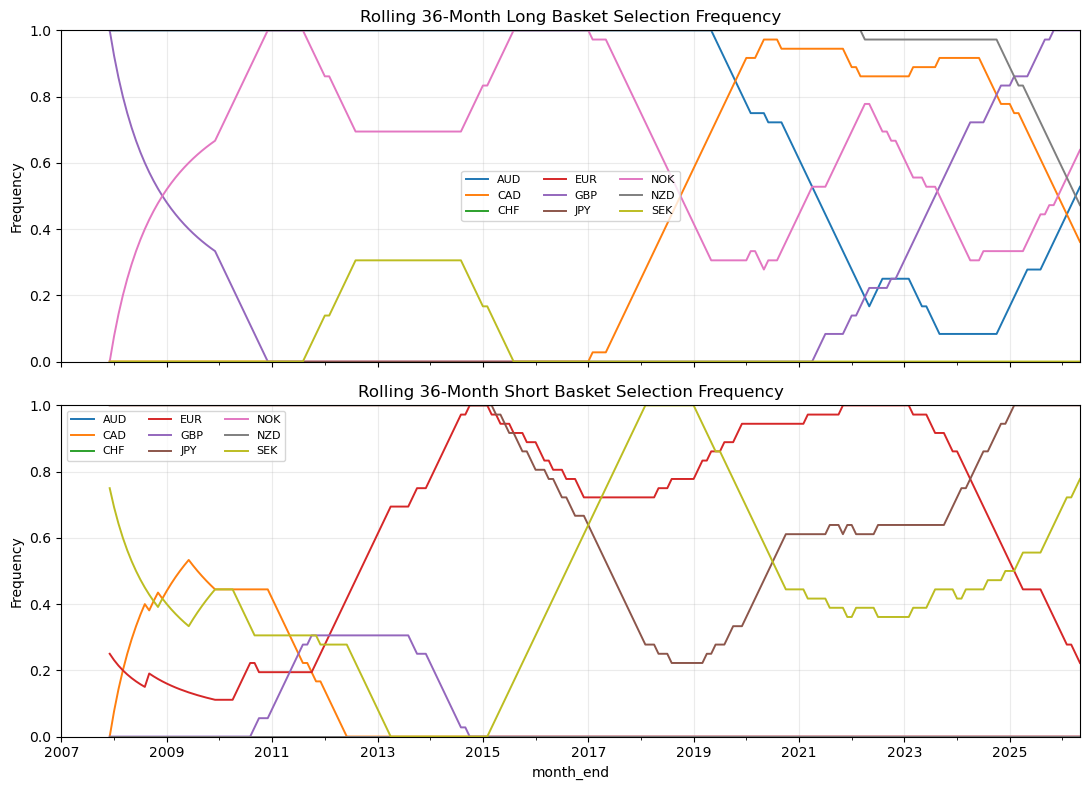

In [9]:
def build_selection_frequency(weights):
    if weights.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    selected = weights.copy()
    selected["is_long"] = (selected["basket"] == "long_high_carry").astype(float)
    selected["is_short"] = (selected["basket"] == "short_low_carry").astype(float)
    full_freq = (selected.groupby("currency")
        .agg(long_selection_rate=("is_long", "mean"), short_selection_rate=("is_short", "mean"))
        .reset_index())
    long_wide = selected.pivot_table(index="month_end", columns="currency", values="is_long", aggfunc="last").sort_index().fillna(0.0)
    short_wide = selected.pivot_table(index="month_end", columns="currency", values="is_short", aggfunc="last").sort_index().fillna(0.0)
    long_roll = long_wide.rolling(36, min_periods=12).mean()
    short_roll = short_wide.rolling(36, min_periods=12).mean()
    return full_freq, long_roll, short_roll

selection_frequency, long_roll, short_roll = build_selection_frequency(weights_panel)
display(selection_frequency.sort_values("long_selection_rate", ascending=False).style.format({"long_selection_rate": "{:.1%}", "short_selection_rate": "{:.1%}"}) if not selection_frequency.empty else selection_frequency)

if plt is None or long_roll.empty:
    display(Markdown("Composition plots skipped because matplotlib is unavailable or no basket weights were created."))
else:
    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    long_roll.plot(ax=axes[0], linewidth=1.4)
    axes[0].set_title("Rolling 36-Month Long Basket Selection Frequency")
    axes[0].set_ylabel("Frequency")
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.25)
    axes[0].legend(ncol=3, fontsize=8)

    short_roll.plot(ax=axes[1], linewidth=1.4)
    axes[1].set_title("Rolling 36-Month Short Basket Selection Frequency")
    axes[1].set_ylabel("Frequency")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)
    axes[1].legend(ncol=3, fontsize=8)

    plt.tight_layout()
    plt.show()


## Crisis-Period Analysis

The periods below are intentionally broad windows for the first baseline diagnostic:

- **2008 global financial crisis:** July 2008 through March 2009
- **2020 Covid shock:** February 2020 through April 2020
- **2022 dollar/rates shock:** January 2022 through October 2022
- **2024/2025 yen/carry unwind period:** July 2024 through January 2025, if available in the panel

These windows can be refined later, but they are good enough to test whether the baseline has the expected carry vulnerability around risk-off episodes.


In [10]:
CRISIS_WINDOWS = [
    {"period": "2008 global financial crisis", "start": "2008-07-31", "end": "2009-03-31"},
    {"period": "2020 Covid shock", "start": "2020-02-29", "end": "2020-04-30"},
    {"period": "2022 dollar/rates shock", "start": "2022-01-31", "end": "2022-10-31"},
    {"period": "2024/2025 yen/carry unwind", "start": "2024-07-31", "end": "2025-01-31"},
]

if portfolio_returns.empty:
    crisis_summary = pd.DataFrame(columns=["period", "start", "end", "months", "period_return", "annualized_volatility", "max_drawdown", "hit_rate", "worst_month", "worst_month_return"])
else:
    rows = []
    for window in CRISIS_WINDOWS:
        start = pd.Timestamp(window["start"])
        end = pd.Timestamp(window["end"])
        sub = portfolio_returns[(portfolio_returns["month_end"] >= start) & (portfolio_returns["month_end"] <= end)].copy()
        r = sub["portfolio_return"].dropna()
        if r.empty:
            rows.append({**window, "months": 0, "period_return": np.nan, "annualized_volatility": np.nan, "max_drawdown": np.nan, "hit_rate": np.nan, "worst_month": "", "worst_month_return": np.nan})
            continue
        worst = sub.loc[sub["portfolio_return"].idxmin()]
        rows.append({
            **window,
            "months": len(r),
            "period_return": (1.0 + r).prod() - 1.0,
            "annualized_volatility": r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR) if len(r) > 1 else np.nan,
            "max_drawdown": max_drawdown(r),
            "hit_rate": (r > 0).mean(),
            "worst_month": worst["month_end"].date().isoformat(),
            "worst_month_return": worst["portfolio_return"],
            "typical_longs": "; ".join(sub["long_currencies"].mode().head(2).tolist()),
            "typical_shorts": "; ".join(sub["short_currencies"].mode().head(2).tolist()),
        })
    crisis_summary = pd.DataFrame(rows)

display(crisis_summary.style.format({
    "period_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "max_drawdown": "{:.2%}",
    "hit_rate": "{:.2%}",
    "worst_month_return": "{:.2%}",
}) if not crisis_summary.empty else crisis_summary)


,period,start,end,months,period_return,annualized_volatility,max_drawdown,hit_rate,worst_month,worst_month_return,typical_longs,typical_shorts
0,2008 global financial crisis,2008-07-31,2009-03-31,9,-15.27%,18.93%,-22.43%,33.33%,2008-09-30,-11.60%,"AUD, NOK, NZD","CAD, CHF, JPY"
1,2020 Covid shock,2020-02-29,2020-04-30,3,-1.43%,18.66%,0.00%,66.67%,2020-02-29,-6.41%,"AUD, CAD, NZD; AUD, NOK, NZD","CHF, EUR, JPY"
2,2022 dollar/rates shock,2022-01-31,2022-10-31,10,3.09%,7.82%,-3.96%,50.00%,2022-08-31,-3.96%,"AUD, CAD, NZD","CHF, EUR, JPY"
3,2024/2025 yen/carry unwind,2024-07-31,2025-01-31,7,-0.17%,2.09%,-1.30%,71.43%,2025-01-31,-1.30%,"GBP, NOK, NZD","CHF, JPY, SEK"


## Baseline Interpretation

The following comments are generated from the results above. They summarize whether the simple G10 carry portfolio behaves plausibly before we move to transaction costs, EM, options, or regime filters.


In [11]:
def pct(x):
    return "n/a" if pd.isna(x) else f"{x:.2%}"

if portfolio_returns.empty or summary.empty or selection_frequency.empty:
    display(Markdown("No interpretation available because the strategy return series was not created."))
else:
    s = summary.iloc[0]
    top_longs = selection_frequency.sort_values("long_selection_rate", ascending=False).head(3)
    top_shorts = selection_frequency.sort_values("short_selection_rate", ascending=False).head(3)
    worst = worst_10_months.iloc[0]

    skew_text = "negative skew" if s["skewness"] < -0.25 else "mild or no negative skew"
    drawdown_text = "material drawdowns" if s["max_drawdown"] < -0.10 else "moderate drawdowns"
    strength_text = "strong enough to justify richer next-step tests" if (s["sharpe_ratio"] > 0.3 and s["months"] >= 60) else "useful as a baseline, but not yet strong enough to judge without costs and robustness checks"

    notes = f"""
### Interpretation Notes

- **Carry-like behavior:** The strategy has an annualized return of {pct(s['annualized_return'])}, annualized volatility of {pct(s['annualized_volatility'])}, and Sharpe ratio of {s['sharpe_ratio']:.2f}. This is the gross, pre-cost baseline.
- **Crash risk:** The max drawdown is {pct(s['max_drawdown'])}, skewness is {s['skewness']:.2f}, and the worst month is {pct(worst['portfolio_return'])} on {worst['month_end'].date().isoformat()}. This points to {skew_text} and {drawdown_text}.
- **Long basket dominance:** The most frequent long-basket currencies are {', '.join(top_longs['currency'])}.
- **Short basket dominance:** The most frequent short-basket currencies are {', '.join(top_shorts['currency'])}.
- **Next-step case:** The result is {strength_text}. The natural next extensions are transaction costs first, then EM carry, options-based crash-risk signals, and regime filters.
"""
    display(Markdown(notes))



### Interpretation Notes

- **Carry-like behavior:** The strategy has an annualized return of 1.87%, annualized volatility of 7.80%, and Sharpe ratio of 0.24. This is the gross, pre-cost baseline.
- **Crash risk:** The max drawdown is -27.26%, skewness is -0.76, and the worst month is -11.60% on 2008-09-30. This points to negative skew and material drawdowns.
- **Long basket dominance:** The most frequent long-basket currencies are NZD, AUD, NOK.
- **Short basket dominance:** The most frequent short-basket currencies are CHF, JPY, EUR.
- **Next-step case:** The result is useful as a baseline, but not yet strong enough to judge without costs and robustness checks. The natural next extensions are transaction costs first, then EM carry, options-based crash-risk signals, and regime filters.


## Scope Check

This notebook stops at the baseline G10 long-short carry strategy. It does not add transaction costs, EM currencies, FX options, macro controls, regime filters, or machine-learning models. Those belong in later notebooks once this benchmark is understood.
